# Relacion 3 b

### Ejercicio 3.3  Hacer el ejercicio 3.11 del Marc Polo



In [ ]:
### LIBRERÍAS #################

from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt

In [4]:
### Constantes universales #######################

hbar = 6.582*10**(-16)     #eV*s

q = 1.602*10**(-19)         #C

kbtz = 8.617*10**(-5)       #eV/K cte de boltzmann 

In [5]:
### Definición de parámetros para los ejercicios ############################3


Ef_0 = -5.0     #eV
Eta = 0.5       
homo = -5.5     #eV
Gamma_s = 0.1   #eV
Gamma_d = 0.1   #eV
T=298           #K
mu_s0 = -5      #eV
mu_d0 = -5      #eV

KT =0.026*T/300 #eV
q_C_es = 1      #eV
Vmax = 4        #eV

numpasos = 101  #Cantidad de pasos desde -Vmax hasta Vmax
maxiteracion = 200   #Como mucho hará 200 iteraciones para encontrar U
precision = 10**(-6)    #Precisión a la hora de converger U
alfa = 0.005              #Constante para la convergencia (Para valores mayores a 0.15 daba resultados raros)
N_0 = 2                 #Número de electrones del homo

In [6]:
### DEFINICION DE LAS FUNCIONES #####################


def fermi(energia, e_fermi):
    """
    Args:
        energia (Float): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    aux = (energia - e_fermi)/(KT)  #Como hay que integrar desde infinito y esto satura, hay que acotar un poco
    if aux < -100:
        return 1.0
    elif aux > 100:
        return 0.0
    else:
        resultado = 1/(1+np.exp((energia - e_fermi)/KT))
        return resultado


#Defino también la densidad de estados

def densidad_g(energia, epsilon, gamma):
    """
    Args:
        energia (Float): Variable de integración
        epsilon (Float): Enegía centrada sobre epsilon (equivalente a mu_0)
        gamma (Float): Camino medio (Gamma_s + Gamma_d)
    """
    resultado = 1/np.pi*gamma/((energia-epsilon)**2+(gamma/2)**2)
    return resultado


def funcion_N(energia, epsilon, gamma, mus, mud, taus, taud):
    """
    Args:
        energia (Float): Variable de integración
        epsilon (Float): Enegía centrada sobre epsilon (equivalente a mu_0)
        gamma (Float): Camino medio (Gamma_s + Gamma_d)
        mus (Float): Nivel de fermi de S
        mud (Float): Nivel de fermi de D
        taus (Float): Tiempo medio de S
        taud (Float): Tiempo medio de D
    """
    resultado = densidad_g(energia, epsilon, gamma)/(taus+taud)*(taud*fermi(energia, mus)+taus*fermi(energia, mud))
    return resultado


def funcion_I(energia, epsilon, gamma, mus, mud, taus, taud):
    """
    Args:
        energia (Float): Variable de integración
        epsilon (Float): Enegía centrada sobre epsilon (equivalente a mu_0)
        gamma (Float): Camino medio (Gamma_s + Gamma_d)
        mus (Float): Nivel de fermi de S
        mud (Float): Nivel de fermi de D
        taus (Float): Tiempo medio de S
        taud (Float): Tiempo medio de D
    """
    resultado = q*densidad_g(energia, epsilon, gamma)/(taus+taud)*(fermi(energia, mus)-fermi(energia, mud))
    return resultado



In [39]:
### CÓDIGO PARA EL EJERCICIO 3.3 #######################################


#Calculamos la función de fermi



Tau_s = hbar / Gamma_s
Tau_d = hbar / Gamma_d
Gamma = Gamma_s + Gamma_d  #Necesaria para la densidad

V = np.linspace(-Vmax, Vmax, numpasos)
N = np.linspace(-Vmax, Vmax, numpasos)
U = np.linspace(-Vmax, Vmax, numpasos)


for i, v in enumerate(V):
    
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    
        
    U_old = 0.0     #Variable auxiliar
    U_new = 0.0     #Variable auxiliar según las pistas
    error = 1.0      #Será la tolerancia que le ponga que tiene que ser menor que la variable 'precision'
    numiteracion = 0 #Cuenta el número de iteración en el que estoy
    
    #Hago un while porque así puede salir del bucle
    
    while error>precision and numiteracion < maxiteracion:
        
        #Plan de acción: Calculo N con U_old, calculo U con esa N, calculo U_new según me dicen las pistas y calculo el nuevo error
        
        Num_e, error_Ne = quad(lambda energia: funcion_N(energia, homo+U_old, Gamma, mu_s, mu_d, Tau_s, Tau_d), -np.inf, np.inf)
        U_aux = q_C_es*(Num_e - N_0)
        U_new = U_old + alfa*(U_aux-U_old)
        error = np.abs(U_new-U_old)
        
        #Ahora actualizo y cambio de iteración.
        U_old = U_new
        numiteracion+=1
    
    #Se supone que ya ha convergido, así que guardo lo obtenido
    
    U[i] = U_old #Puedo poner aquí U_new o U_old, porque a la hora de terminar son iguales.
    N[i] = Num_e
    

In [40]:
### CÓDIGO PARA HACER LA INTENSIDAD ##############################

I = np.linspace(-Vmax, Vmax, numpasos)
err_I = np.linspace(-Vmax, Vmax, numpasos)

for i, v in enumerate(V):
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    I[i], err_I[i] = quad(lambda energia: funcion_I(energia, homo+U[i], Gamma, mu_s, mu_d, Tau_s, Tau_d), -np.inf, np.inf)

G = np.gradient(I,V)

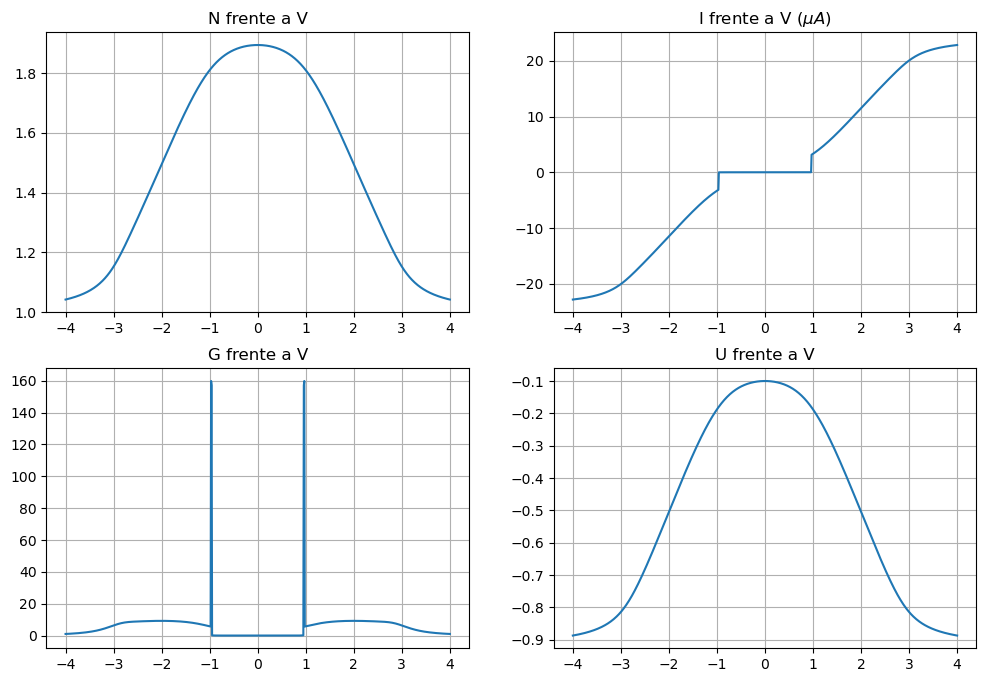

In [41]:
### PLOT PARA EL EJERCICIO 3.3 #####################################

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(V,N, label = "N-V")
plt.title("N frente a V")
plt.grid()

plt.subplot(2,2,2)
plt.plot(V, I*10**6, label="I-V")
plt.title(r"I frente a V ($\mu A$)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(V,G*10**6, label="G-V")
plt.title("G frente a V")
plt.grid()

plt.subplot(2,2,4)
plt.plot(V,U, label="U-V")
plt.title("U frente a V")
plt.grid()

No he conseguido quitarme el escalón abrupto de la intensidad. Si lo ignoramos tenemos una curva de conductancia y de intensidad que alcanza los valores pico en las mismas coordenadas que en el libro Marc Baldo.

##### Apartado b
**How would you expect the IV to change if $\Gamma_s$ > $\Gamma_D$? Explain.**

Si incrementamos alguna $\Gamma$ estamos aumentando el contacto y por ello disminuyendo el tiempo $\tau$, por lo que los electrones circularían con mayor facilidad en esa dirección y por tanto la curva se ensancha y ya depende cada vez más del drenador (en este caso). Cuando incrementamos una (y no la otra) obtenemos una curva bastante asimétrica.

Si queremos cambiar las gamma, es solamente cambiar en la primera celda de constantes, las variables Gamma_s y Gamma_d